In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [51]:
ROUBOS = r'C:\Users\aluno.santaluzia\Documents\Enzo\Bases\03.BaseDPEvolucaoMensalCisp.csv'
DP = r'C:\Users\aluno.santaluzia\Documents\Enzo\Bases\08.DP.csv'

df_roubos = pd.read_csv(
    ROUBOS,
    sep=';',
    encoding='iso-8859-1'
)

df_DP = pd.read_csv(
    DP
)

df_DP

,codDP,nome,endereco
0,1,001ª DP - Praça da República,"Av. Presidente Vargas, 1100 - Centro, Rio de J..."
1,4,004ª DP - Praça da República,"Av. Presidente Vargas, 1100 - Centro, Rio de J..."
2,5,005ª DP - Mem de Sá,"Avenida Gomes Freire, 320 - Centro, Rio de Jan..."
3,6,006ª DP - Cidade Nova,"Rua Professor Clementino Fraga, 77 - Centro, R..."
4,7,007ª DP - Santa Teresa,"Rua Francisco de Castro, 5 - Santa Teresa, Rio..."
...,...,...,...
132,159,159ª DP - Cachoeira de Macacu,"Avenida Lord Baden Powel, 93 - Centro, Cachoei..."
133,165,165ª DP - Mangaratiba,"Estrada São João Marcos, s/n - Praia do Saco, ..."
134,166,166ª DP - Angra dos Reis,"Rua Doutor Coutinho, 6 - Centro, Angra dos Rei..."
135,167,167ª DP - Paraty,"Rua Roberto da Silveira , s/n - Vila Colonial,..."


In [52]:
df_merge = df_roubos.merge(
    df_DP, # com quem juntar
    how='left', # como juntar (inner, left, outer)
    right_on='codDP', # coluna da tabela a direita (com quem juntar)
    left_on='cisp' # coluna da tabela a esquerda (quem chamou)
)
df_merge.head()

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,codDP,nome,endereco
0,1,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,2,0,0,0,0,578,3,1.0,001ª DP - Praça da República,"Av. Presidente Vargas, 1100 - Centro, Rio de J..."
1,4,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,6,0,1,0,0,441,3,4.0,004ª DP - Praça da República,"Av. Presidente Vargas, 1100 - Centro, Rio de J..."
2,5,1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,2,1,0,0,0,637,3,5.0,005ª DP - Mem de Sá,"Avenida Gomes Freire, 320 - Centro, Rio de Jan..."
3,6,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,2,1,0,0,0,473,3,6.0,006ª DP - Cidade Nova,"Rua Professor Clementino Fraga, 77 - Centro, R..."
4,7,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,1,3,0,0,0,147,3,7.0,007ª DP - Santa Teresa,"Rua Francisco de Castro, 5 - Santa Teresa, Rio..."


In [53]:
df_roubo_celular = df_merge[[
        'nome', 'roubo_celular', 'ano'
]]
df_roubo_transeunte = df_merge[[
        'nome', 'roubo_transeunte', 'ano'
]]

In [54]:
df_roubo_celular_por_dp = (
    df_roubo_celular.groupby('nome')['roubo_celular']
    .sum().reset_index()
    .sort_values(by='roubo_celular', ascending=False)
)
df_roubo_celular_por_dp.head(10)


,nome,roubo_celular
51,059ª DP - Duque de Caxias,12319
56,064ª DP - São João de Meriti,9414
30,034ª DP - Bangu,8771
25,029ª DP - Madureira,7814
29,033ª DP - Realengo,7175
2,005ª DP - Mem de Sá,6912
19,023ª DP - Méier,6824
23,027ª DP - Vicente de Carvalho,6574
31,035ª DP - Campo Grande,6332
44,052ª DP - Nova Iguaçu,6262


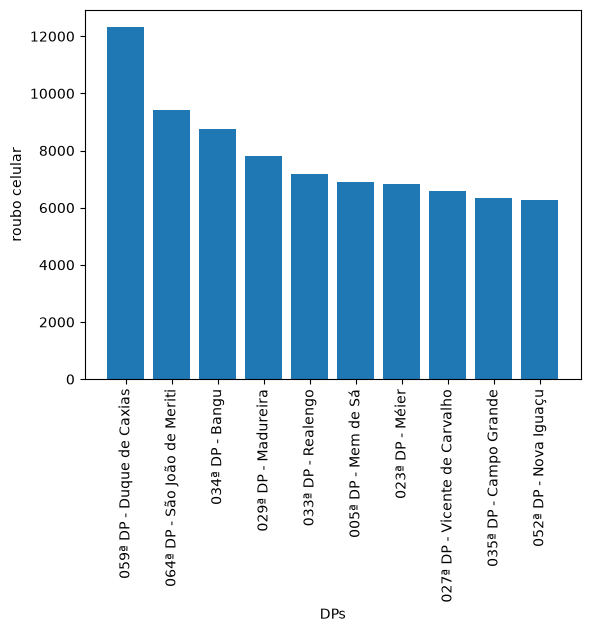

In [55]:
plt.bar(df_roubo_celular_por_dp ['nome'].iloc[0:10],
         df_roubo_celular_por_dp['roubo_celular'].iloc[0:10])
plt.xticks(rotation=90)
plt.ylabel('roubo celular')
plt.xlabel('DPs')
plt.show()

In [56]:
roubo_celular_array = np.array(df_roubo_celular_por_dp['roubo_celular'])

media = np.mean(roubo_celular_array)
mediana = np.median(roubo_celular_array)
desvio = np.std(roubo_celular_array)

q1 = np.percentile(roubo_celular_array, 25)
q3 = np.percentile(roubo_celular_array, 75)
iqr = q3 - q1

# outliers - preparação
limite_inferior = q1 - 1.5*iqr
limite_superior = q3 + 1.5*iqr

In [57]:
print(f'Media: {media}')
print(f'Mediana: {mediana}')
print(f'Desvio Padrão: {desvio}')
print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'Limite Inferior: {limite_inferior}')
print(f'Limite Superior: {limite_superior}')

Media: 2026.4087591240875
Mediana: 729.0
Desvio Padrão: 2469.739140912832
Q1: 47.0
Q3: 3767.0
Limite Inferior: -5533.0
Limite Superior: 9347.0


In [58]:
df_roubo_celular_outliers_inf = (
df_roubo_celular_por_dp[df_roubo_celular_por_dp['roubo_celular'] < limite_inferior]
)

df_roubo_celular_outliers_sup = (
df_roubo_celular_por_dp[df_roubo_celular_por_dp['roubo_celular'] > limite_superior]
)

In [59]:
if len(df_roubo_celular_outliers_inf ) <= 0:
    print('Não há Outliers Inferiores')
else:
    print(f'Há {len(df_roubo_celular_outliers_inf)} Outliers Inferiores')

if len(df_roubo_celular_outliers_sup) <= 0:
    print('Não há Outliers Superiores')
else:
    print(f'Há {len(df_roubo_celular_outliers_sup)} Outliers Superiores')

Não há Outliers Inferiores
Há 2 Outliers Superiores


In [60]:
df_roubo_transeunte_por_dp = (
    df_roubo_transeunte.groupby('nome')['roubo_transeunte']
    .sum().reset_index()
    .sort_values(by='roubo_transeunte', ascending=False)
)
df_roubo_transeunte_por_dp.head(10)


,nome,roubo_transeunte
51,059ª DP - Duque de Caxias,59518
56,064ª DP - São João de Meriti,43262
30,034ª DP - Bangu,42713
64,074ª DP - Alcântara,35892
25,029ª DP - Madureira,31430
2,005ª DP - Mem de Sá,29650
23,027ª DP - Vicente de Carvalho,28495
44,052ª DP - Nova Iguaçu,27815
31,035ª DP - Campo Grande,27571
46,054ª DP - Belford Roxo,27521


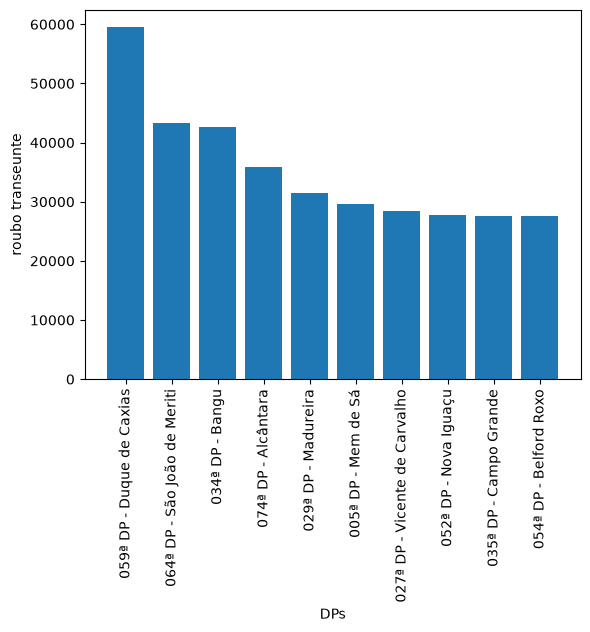

In [61]:
plt.bar(df_roubo_transeunte_por_dp ['nome'].iloc[0:10],
         df_roubo_transeunte_por_dp['roubo_transeunte'].iloc[0:10])
plt.xticks(rotation=90)
plt.ylabel('roubo transeunte')
plt.xlabel('DPs')
plt.show()

In [62]:
roubo_transeunte_array = np.array(df_roubo_transeunte_por_dp['roubo_transeunte'])

media = np.mean(roubo_transeunte_array)
mediana = np.median(roubo_transeunte_array)
desvio = np.std(roubo_transeunte_array)

q1 = np.percentile(roubo_transeunte_array, 25)
q3 = np.percentile(roubo_transeunte_array, 75)
iqr = q3 - q1

# outliers - preparação
limite_inferior = q1 - 1.5*iqr
limite_superior = q3 + 1.5*iqr

In [63]:
print(f'Media: {media}')
print(f'Mediana: {mediana}')
print(f'Desvio Padrão: {desvio}')
print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'Limite Inferior: {limite_inferior}')
print(f'Limite Superior: {limite_superior}')

Media: 8886.058394160584
Mediana: 3853.0
Desvio Padrão: 10987.140113778552
Q1: 185.0
Q3: 16159.0
Limite Inferior: -23776.0
Limite Superior: 40120.0


In [64]:
df_roubo_transeunte_outliers_inf = (
df_roubo_transeunte_por_dp[df_roubo_transeunte_por_dp['roubo_transeunte'] < limite_inferior]
)

df_roubo_transeunte_outliers_sup = (
df_roubo_transeunte_por_dp[df_roubo_transeunte_por_dp['roubo_transeunte'] > limite_superior]
)

In [65]:
if len(df_roubo_transeunte_outliers_inf) <= 0:
    print('Não há Outliers Inferiores')
else:
    print(f'Há {len(df_roubo_transeunte_outliers_inf)} Outliers Inferiores')

if len(df_roubo_transeunte_outliers_sup) <= 0:
    print('Não há Outliers Superiores')
else:
    print(f'Há {len(df_roubo_transeunte_outliers_sup)} Outliers Superiores')

Não há Outliers Inferiores
Há 3 Outliers Superiores


In [66]:
#COMENTÁRIOS 

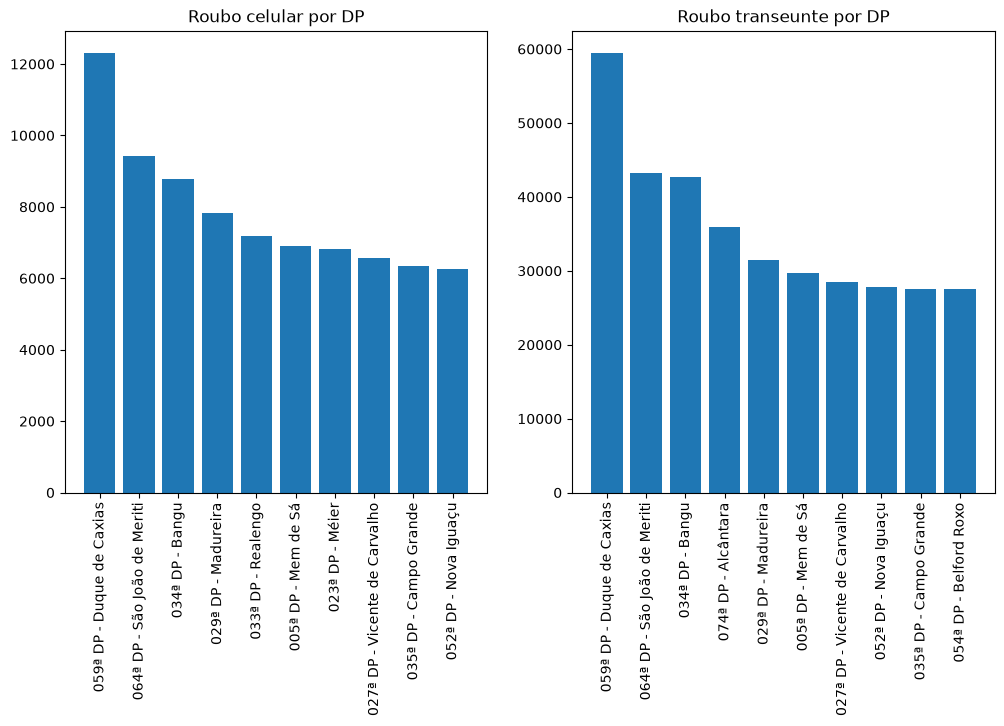

In [67]:
plt.subplots(1, 2, figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(df_roubo_celular_por_dp ['nome'].iloc[0:10],
         df_roubo_celular_por_dp['roubo_celular'].iloc[0:10])
plt.title('Roubo celular por DP')
plt.xticks(rotation=90)

plt.subplot(1, 2, 2)

plt.bar(df_roubo_transeunte_por_dp ['nome'].iloc[0:10],
         df_roubo_transeunte_por_dp['roubo_transeunte'].iloc[0:10])
plt.title('Roubo transeunte por DP')
plt.xticks(rotation=90)
plt.show()

In [68]:
# COMENTÁRIOS
# Esses gráficos nos mostra as 10 DPs com mais roubos de celulares de roubos transeuntes
# e para determinar as zonas vermelhas, uma soma será feita entre roubo transeunte e 
# roubo celular por DPs e as DPs que aparecerem no top 10 serão zonas vermelhas

In [69]:
somaData = df_roubo_transeunte_por_dp.merge(df_roubo_celular_por_dp,on='nome', how='left')
somaData.head(10)

,nome,roubo_transeunte,roubo_celular
0,059ª DP - Duque de Caxias,59518,12319
1,064ª DP - São João de Meriti,43262,9414
2,034ª DP - Bangu,42713,8771
3,074ª DP - Alcântara,35892,4910
4,029ª DP - Madureira,31430,7814
5,005ª DP - Mem de Sá,29650,6912
6,027ª DP - Vicente de Carvalho,28495,6574
7,052ª DP - Nova Iguaçu,27815,6262
8,035ª DP - Campo Grande,27571,6332
9,054ª DP - Belford Roxo,27521,5770


In [70]:
somaData['total'] = somaData['roubo_transeunte']+somaData['roubo_celular']
somaData.head(10)

top10= somaData.sort_values(by='total', ascending=False)
top10.head(10)

,nome,roubo_transeunte,roubo_celular,total
0,059ª DP - Duque de Caxias,59518,12319,71837
1,064ª DP - São João de Meriti,43262,9414,52676
2,034ª DP - Bangu,42713,8771,51484
3,074ª DP - Alcântara,35892,4910,40802
4,029ª DP - Madureira,31430,7814,39244
5,005ª DP - Mem de Sá,29650,6912,36562
6,027ª DP - Vicente de Carvalho,28495,6574,35069
7,052ª DP - Nova Iguaçu,27815,6262,34077
8,035ª DP - Campo Grande,27571,6332,33903
9,054ª DP - Belford Roxo,27521,5770,33291


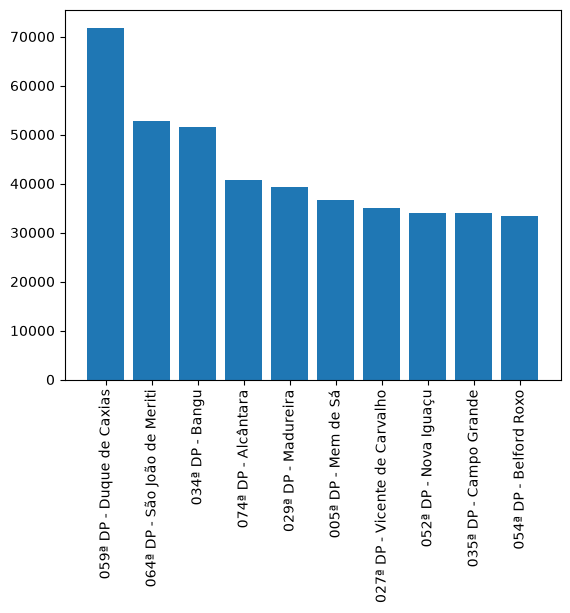

In [71]:
# Gráfico do total da soma 
plt.bar(somaData ['nome'].iloc[0:10],
         somaData ['total'].iloc[0:10])
plt.xticks(rotation=90)
plt.show()

In [72]:
# As áreas classificadas como zonas vermelhas apresentam um nível de risco mais elevado. 
# Por esse motivo, o custo do seguro nessas regiões tende a ser maior, 
# pois as seguradoras ajustam o valor do prêmio de acordo com a probabilidade de ocorrência de sinistros. 
# Assim, imóveis localizados em zonas vermelhas geralmente terão um seguro mais caro 
# em comparação com aqueles situados em áreas de menor risco.

# Existe uma correlação fortemente positiva entre roubo de celular e roubo transeunte

In [73]:
# MÉDIA, MODA E MEDIANA

roubo_celular_array = np.array(df_roubo_celular_por_dp['roubo_celular'])

media = np.mean(roubo_celular_array)
mediana = np.median(roubo_celular_array)
desvio = np.std(roubo_celular_array)
moda = df_roubo_celular_por_dp['roubo_celular'].mode()

q1 = np.percentile(roubo_celular_array, 25)
q3 = np.percentile(roubo_celular_array, 75)
iqr = q3 - q1

# outliers - preparação
limite_inferior = q1 - 1.5*iqr
limite_superior = q3 + 1.5*iqr

delta_media_mediana = media - mediana
div_media_mediana = media/mediana


print(f'Media: {media}')
print(f'Mediana: {mediana}')
print(f'Desvio Padrão: {desvio}')
print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'Limite Inferior: {limite_inferior}')
print(f'Limite Superior: {limite_superior}')
print(f'A moda é: {moda}')
print(f'A diferença entre a média e a mediana é: {delta_media_mediana:.2f}')
print(f'A razão entre a média e a mediana é: {div_media_mediana:.2f}')

# O delta positivo com a assimetria positiva indica que tiveram meses com 
# maiores números de roubos, aumentando a média para cima. Para o negócio, 
# isso indica a existência de meses com maior criminanlidade, que devem ser 
# analisados separadamente, pois influencia nos demais.


Media: 2026.4087591240875
Mediana: 729.0
Desvio Padrão: 2469.739140912832
Q1: 47.0
Q3: 3767.0
Limite Inferior: -5533.0
Limite Superior: 9347.0
A moda é: 0    3
Name: roubo_celular, dtype: int64
A diferença entre a média e a mediana é: 1297.41
A razão entre a média e a mediana é: 2.78


In [74]:
roubo_transeunte_array = np.array(df_roubo_transeunte_por_dp['roubo_transeunte'])

media = np.mean(roubo_transeunte_array)
mediana = np.median(roubo_transeunte_array)
desvio = np.std(roubo_transeunte_array)

q1 = np.percentile(roubo_transeunte_array, 25)
q3 = np.percentile(roubo_transeunte_array, 75)
iqr = q3 - q1

# outliers - preparação
limite_inferior = q1 - 1.5*iqr
limite_superior = q3 + 1.5*iqr

delta_media_mediana = media - mediana
div_media_mediana = media/mediana

print(f'Media: {media}')
print(f'Mediana: {mediana}')
print(f'Desvio Padrão: {desvio}')
print(f'Q1: {q1}')
print(f'Q3: {q3}')
print(f'Limite Inferior: {limite_inferior}')
print(f'Limite Superior: {limite_superior}')
print(f'A diferença entre a média e a mediana é: {delta_media_mediana:.2f}')
print(f'A razão entre a média e a mediana é: {div_media_mediana:.2f}')

# O MESMO TEXTO DE CIMA

# O delta positivo com a assimetria positiva indica que tiveram meses com 
# maiores números de roubos, aumentando a média para cima. Para o negócio, 
# isso indica a existência de meses com maior criminanlidade, que devem ser 
# analisados separadamente, pois influencia nos demais.




Media: 8886.058394160584
Mediana: 3853.0
Desvio Padrão: 10987.140113778552
Q1: 185.0
Q3: 16159.0
Limite Inferior: -23776.0
Limite Superior: 40120.0
A diferença entre a média e a mediana é: 5033.06
A razão entre a média e a mediana é: 2.31


In [75]:
# VERIFICAÇÃO DE OUTLIERS
# TRAÇANDO LIMITES

df_roubo_celular_outliers_inf = (
df_roubo_celular_por_dp[df_roubo_celular_por_dp['roubo_celular'] < limite_inferior]
)

df_roubo_celular_outliers_sup = (
df_roubo_celular_por_dp[df_roubo_celular_por_dp['roubo_celular'] > limite_superior]
)

In [76]:
# IF E ELSE PARA VERIFICAR OS LIMITES

if len(df_roubo_celular_outliers_inf ) <= 0:
    print('Não há Outliers Inferiores')
else:
    print(f'Há {len(df_roubo_celular_outliers_inf)} Outliers Inferiores')

if len(df_roubo_celular_outliers_sup) <= 0:
    print('Não há Outliers Superiores')
else:
    print(f'Há {len(df_roubo_celular_outliers_sup)} Outliers Superiores')

Não há Outliers Inferiores
Não há Outliers Superiores


In [77]:
# TRAÇANDO LIMITES

df_roubo_transeunte_outliers_inf = (
df_roubo_transeunte_por_dp[df_roubo_transeunte_por_dp['roubo_transeunte'] < limite_inferior]
)

df_roubo_transeunte_outliers_sup = (
df_roubo_transeunte_por_dp[df_roubo_transeunte_por_dp['roubo_transeunte'] > limite_superior]
)

In [78]:
# IF E ELSE PARA VERIFICAR OS LIMITES

if len(df_roubo_transeunte_outliers_inf) <= 0:
    print('Não há Outliers Inferiores')
else:
    print(f'Há {len(df_roubo_transeunte_outliers_inf)} Outliers Inferiores')

if len(df_roubo_transeunte_outliers_sup) <= 0:
    print('Não há Outliers Superiores')
else:
    print(f'Há {len(df_roubo_transeunte_outliers_sup)} Outliers Superiores')

Não há Outliers Inferiores
Há 3 Outliers Superiores


In [79]:
#ASSIMETRIA E CURTOSE

assimetria = df_roubo_celular_por_dp['roubo_celular'].skew()
curtose = df_roubo_celular_por_dp['roubo_celular'].kurtosis()

print(f'Assimetria: {assimetria:.4f}')
print(f'Curtose: {curtose:.4f}')

# A assimetria indica uma cauda longa para a direita, há DPs que puxam a distribuição
# para a direita. A curtose indica que há mais valores extremos do que uma distruição normal.

Assimetria: 1.3339
Curtose: 1.6347


In [80]:
assimetria = df_roubo_transeunte_por_dp['roubo_transeunte'].skew()
curtose = df_roubo_transeunte_por_dp['roubo_transeunte'].kurtosis()

print(f'Assimetria: {assimetria:.4f}')
print(f'Curtose: {curtose:.4f}')

# assimetria forte cauda para direita
# caudas pesadas e tendência de outliers

Assimetria: 1.5577
Curtose: 3.0193


In [81]:
# RESPONDENDO A NÚMERO 3
outliers = df_roubo_transeunte_por_dp[
    df_roubo_transeunte_por_dp['roubo_transeunte'] > limite_superior
]

print(outliers)

                            nome  roubo_transeunte
51     059ª DP - Duque de Caxias             59518
56  064ª DP - São João de Meriti             43262
30               034ª DP - Bangu             42713


In [82]:
outliers_por_dp = (
    outliers.groupby('nome')['roubo_transeunte']
    .count()
    .sort_values(ascending=False)
)

print(outliers_por_dp)

#COMENTÁRIOS
# Apenas 3 outliers foram identificados em roubo_transeunte e nenhum outilier 
# foi identificado em roubo_celular.
# Os 3 outliers identificados em roubo_transeunte são: Bangu, Duque de Caxias e São João de Meriti.

nome
034ª DP - Bangu                 1
059ª DP - Duque de Caxias       1
064ª DP - São João de Meriti    1
Name: roubo_transeunte, dtype: int64


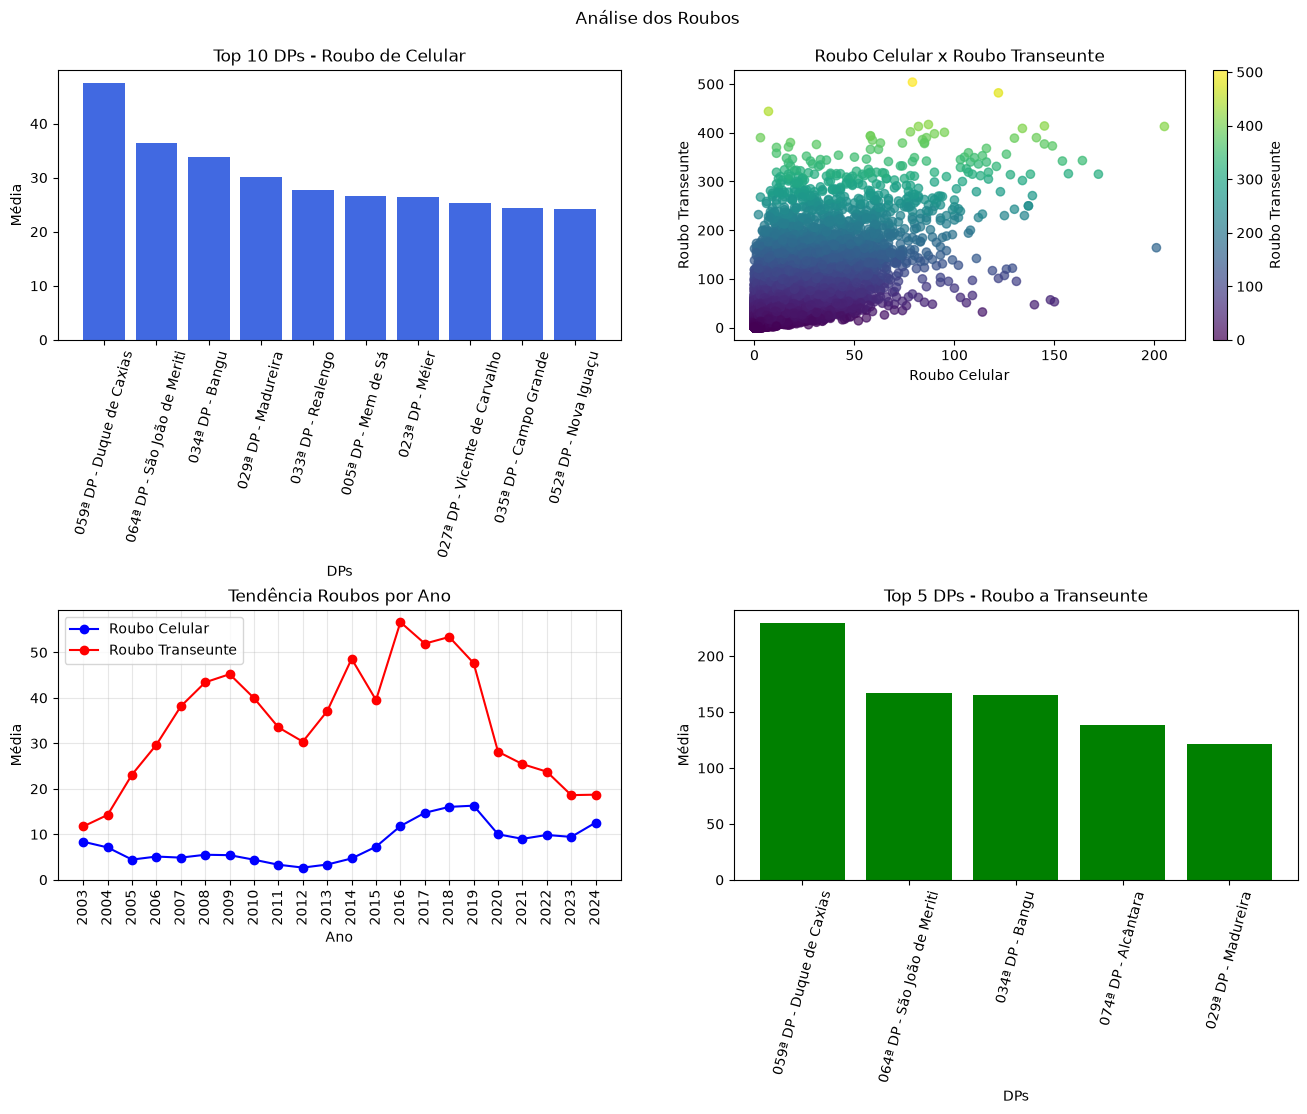

In [87]:
# A CRIAÇÃO DOS QUATRO QUADRANTES

plt.figure(figsize=(16,10))


# 1º QUADRANTE 


plt.subplot(2,2,1)

top10_celular = (
    df_merge.groupby('nome')['roubo_celular']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.bar(top10_celular.index, top10_celular.values, color='royalblue')

plt.title('Top 10 DPs - Roubo de Celular')
plt.xlabel('DPs')
plt.ylabel('Média')
plt.xticks(rotation=75)


# 2º QUADRANTE 


plt.subplot(2,2,2)

plt.scatter(
    df_roubo_celular['roubo_celular'],
    df_roubo_transeunte['roubo_transeunte'],
    c=df_roubo_transeunte['roubo_transeunte'],
    cmap='viridis',
    alpha=0.7
)

plt.colorbar(label='Roubo Transeunte')
plt.title('Roubo Celular x Roubo Transeunte')
plt.xlabel('Roubo Celular')
plt.ylabel('Roubo Transeunte')


# 3º QUADRANTE 


plt.subplot(2,2,3)

media_ano = df_merge.groupby('ano')[['roubo_celular','roubo_transeunte']].mean()

plt.plot(
    media_ano.index,
    media_ano['roubo_celular'],
    marker='o',
    color='blue',
    label='Roubo Celular'
)

plt.plot(
    media_ano.index,
    media_ano['roubo_transeunte'],
    marker='o',
    color='red',
    label='Roubo Transeunte'
)

plt.title('Tendência Roubos por Ano')
plt.xlabel('Ano')
plt.ylabel('Média')

plt.xticks(media_ano.index, rotation=90)

plt.legend()
plt.grid(alpha=0.3)


# 4º QUADRANTE


plt.subplot(2,2,4)

top10_transeunte = (
    df_merge.groupby('nome')['roubo_transeunte']
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

plt.bar(top10_transeunte.index, top10_transeunte.values, color='green')

plt.title('Top 5 DPs - Roubo a Transeunte')
plt.xlabel('DPs')
plt.ylabel('Média')
plt.xticks(rotation=75)


plt.suptitle('Análise dos Roubos')

plt.subplots_adjust(
    hspace=1,
    wspace=0.2,
    top=0.92
)

plt.show()

In [84]:
#COMENTÁRIOS 
# QUADRANTE 1 - Os 3 outliers identificaram foram: Duque de Caxias, São João de Meriti e Bangu

# QUADRANTE 2 - Há uma relação fortemente positiva. Em geral, quando o roubo de celular aumenta,
# a transeunte tende a aumentar também

# QUADRANTE 3 - Em 2018/2019 a tendência de roubos aumentaram e a partir de 2020, houve uma queda.
# Não há como afirmar se a a tendência é aumentar ou diminuir a quantidade de roubos. Sempre quando atinge
# uma alta vem uma queda logo em seguida

In [85]:
correlacao = df_merge['roubo_celular'].corr(df_merge['roubo_transeunte'])

print(f'Correlação: {correlacao:.4f}')

Correlação: 0.7154
